#Predição de Churn na Telecom X: Inteligência de Dados para Retenção de Clientes

A retenção de clientes é um dos pilares estratégicos da Telecom X. Após uma análise exploratória detalhada, avançamos para a fase de Inteligência Preditiva. Este projeto apresenta o desenvolvimento de um pipeline de Machine Learning focado em antecipar o comportamento de cancelamento (Churn). Utilizando técnicas avançadas de pré-processamento, balanceamento de dados (SMOTE) e comparação de modelos de classificação, buscamos não apenas prever a saída de clientes, mas identificar as causas raízes que influenciam essa decisão, permitindo que a empresa atue de forma proativa e estratégica.

###Carregamento

In [7]:
import requests
import pandas as pd
import numpy as np

# URL oficial do curso
URL_FONTE = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

response = requests.get(URL_FONTE)
data = response.json()

# 1. Expandir o JSON (Flattening)
df_telecom = pd.json_normalize(data)

# 2. Limpar os nomes das colunas (ex: 'account.TotalCharges' vira apenas 'TotalCharges')
df_telecom.columns = [col.split('.')[-1] for col in df_telecom.columns]

# 3. Converter a coluna alvo (Churn) para numérico
# O dataset original usa 'No'/'Yes'. O modelo precisa de 0/1.
if 'Churn' in df_telecom.columns:
    df_telecom['Churn'] = df_telecom['Churn'].map({'No': 0, 'Yes': 1})

# 4. Converter colunas numéricas que vieram como texto (Strings)
# O pandas vai tentar converter o que for possível; o que não for (texto puro), ele ignora.
for col in df_telecom.columns:
    # Tenta converter para numérico, se falhar, mantém como está
    df_telecom[col] = pd.to_numeric(df_telecom[col], errors='ignore')

print("✅ Colunas identificadas:", df_telecom.columns.tolist())
df_telecom.head()

✅ Colunas identificadas: ['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total']


/tmp/ipykernel_218/2901941956.py:26: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_telecom[col] = pd.to_numeric(df_telecom[col], errors='ignore')


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


###Analise de correlação

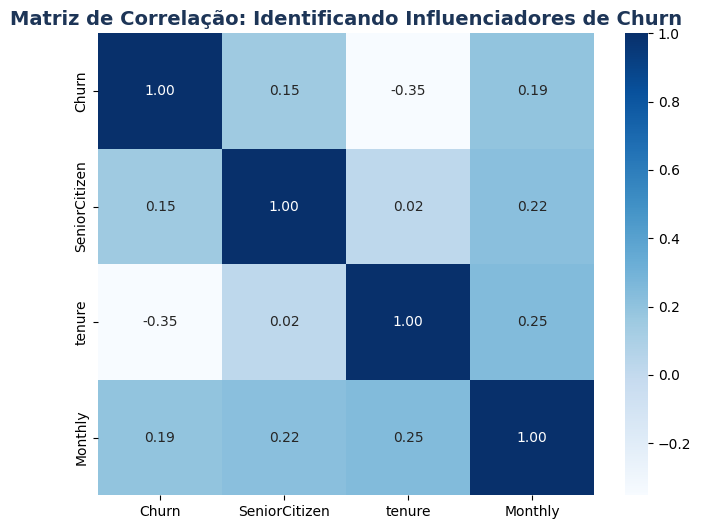

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Filtrar apenas as colunas que agora são numéricas após o "achatamento" do JSON
df_numerico = df_telecom.select_dtypes(include=[np.number])

# 2. Calcular a correlação entre todas as variáveis numéricas
corr = df_numerico.corr()

# 3. Configurar e exibir o gráfico de calor (Heatmap) com sua paleta de azuis
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", cbar=True)

# 4. Personalizar o título para o seu relatório de Analista Júnior
plt.title('Matriz de Correlação: Identificando Influenciadores de Churn', fontsize=14, fontweight='bold', color='#1d3557')
plt.show()

📊 ANÁLISE DE EQUILÍBRIO DE CLASSES
-----------------------------------
Classe 0.0: 73.46% (5174 clientes)
Classe 1.0: 26.54% (1869 clientes)


/tmp/ipykernel_218/2841160668.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=proporcao_classes.index, y=proporcao_classes.values, palette='Blues')


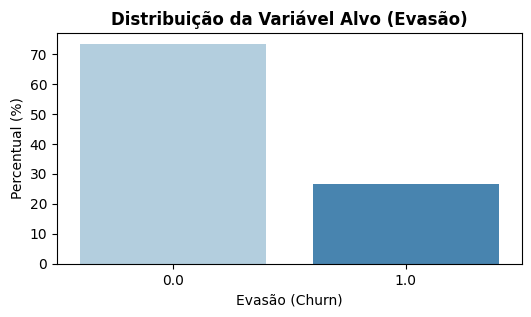


⚠️ ALERTA: Há um desequilíbrio entre as classes.
Isso pode impactar os modelos. Recomenda-se usar SMOTE no próximo passo.


In [13]:
# 1. Identificar o nome da coluna de Churn
coluna_churn = 'Churn' if 'Churn' in df_telecom.columns else 'churn'

# 2. Calcular a contagem e a proporção
contagem_classes = df_telecom[coluna_churn].value_counts()
proporcao_classes = df_telecom[coluna_churn].value_counts(normalize=True) * 100

print("📊 ANÁLISE DE EQUILÍBRIO DE CLASSES")
print("-" * 35)
for classe, percentual in proporcao_classes.items():
    qtd = contagem_classes[classe]
    print(f"Classe {classe}: {percentual:.2f}% ({qtd} clientes)")

# 3. Visualização Gráfica
plt.figure(figsize=(6, 3))
sns.barplot(x=proporcao_classes.index, y=proporcao_classes.values, palette='Blues')
plt.title('Distribuição da Variável Alvo (Evasão)', fontsize=12, fontweight='bold')
plt.ylabel('Percentual (%)')
plt.xlabel('Evasão (Churn)')
plt.show()

# 4. Avaliação de Desequilíbrio (Objetivo do Desafio)
if proporcao_classes.min() < 40:
    print("\n⚠️ ALERTA: Há um desequilíbrio entre as classes.")
    print("Isso pode impactar os modelos. Recomenda-se usar SMOTE no próximo passo.")

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Preparação de X e y
# Removemos colunas de ID e a própria resposta do conjunto de perguntas (X)
X = pd.get_dummies(df_telecom.drop(columns=['Churn', 'customerID', 'Churn_Num'], errors='ignore'))
y = df_telecom['Churn'].map({'No': 0, 'Yes': 1, 0: 0, 1: 1})

# --- CORREÇÃO DE NANS ---
# Unimos X e y temporariamente para remover linhas onde o 'y' (Churn) seja nulo
df_temp = pd.concat([X, y], axis=1).dropna(subset=['Churn'])
X = df_temp.drop(columns=['Churn'])
y = df_temp['Churn']
# ------------------------

# 2. Divisão Treino/Teste (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Balanceamento com SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Normalização (Escalonamento)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print(f"⚖️ Pré-processamento concluído!")
print(f"Dados após limpeza e SMOTE: {len(X_train_res)} amostras para treino.")

⚖️ Pré-processamento concluído!
Dados após limpeza e SMOTE: 7224 amostras para treino.


📊 RELATÓRIO: REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

         0.0       0.88      0.73      0.80      1562
         1.0       0.48      0.72      0.58       551

    accuracy                           0.73      2113
   macro avg       0.68      0.72      0.69      2113
weighted avg       0.78      0.73      0.74      2113


🌲 RELATÓRIO: RANDOM FOREST
              precision    recall  f1-score   support

         0.0       0.84      0.88      0.86      1562
         1.0       0.59      0.52      0.55       551

    accuracy                           0.78      2113
   macro avg       0.72      0.70      0.70      2113
weighted avg       0.77      0.78      0.78      2113



<Figure size 800x600 with 0 Axes>

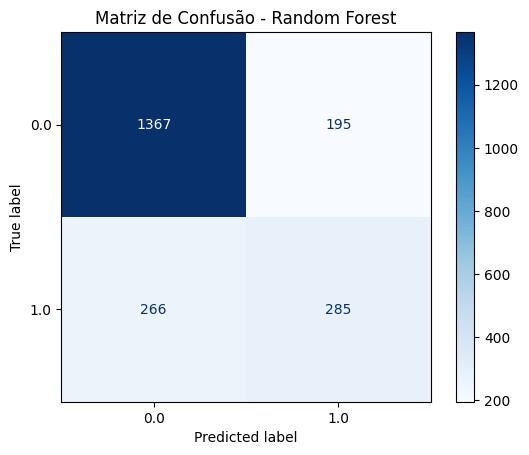

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Instanciando e treinando os modelos com os dados balanceados (SMOTE)
modelo_lr = LogisticRegression(max_iter=1000)
modelo_lr.fit(X_train_scaled, y_train_res)

modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train_scaled, y_train_res)

# 2. Realizando as previsões
pred_lr = modelo_lr.predict(X_test_scaled)
pred_rf = modelo_rf.predict(X_test_scaled)

# 3. Exibindo os relatórios de métricas (Acurácia, Precisão, Recall e F1-Score)
print("📊 RELATÓRIO: REGRESSÃO LOGÍSTICA")
print(classification_report(y_test, pred_lr))

print("\n🌲 RELATÓRIO: RANDOM FOREST")
print(classification_report(y_test, pred_rf))

# 4. Visualizando a Matriz de Confusão do Random Forest (Geralmente o melhor modelo)
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(modelo_rf, X_test_scaled, y_test, cmap='Blues')
plt.title('Matriz de Confusão - Random Forest')
plt.grid(False)
plt.show()

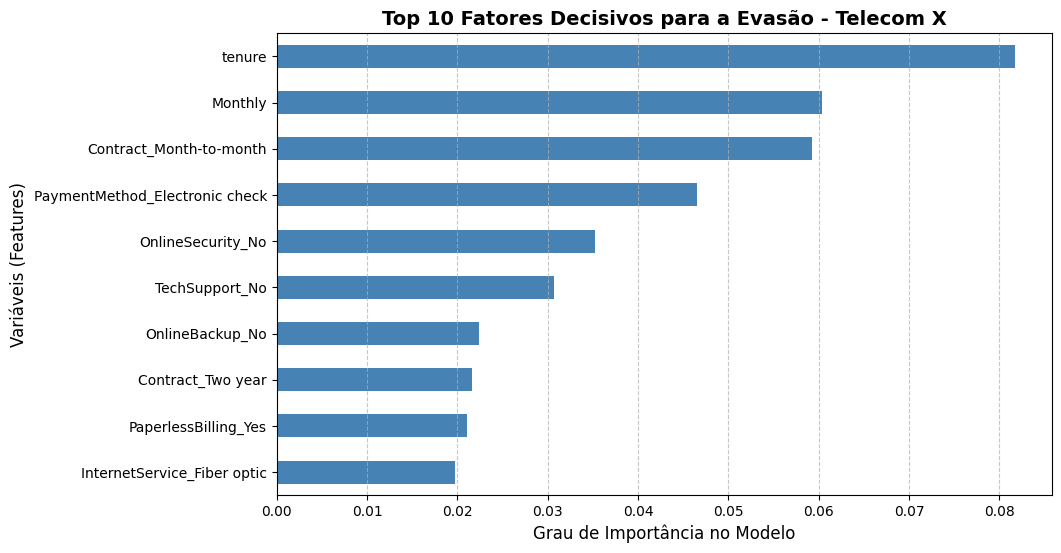

🔍 INSIGHTS PARA O TIME DE NEGÓCIO:
Os fatores abaixo são os que mais geram probabilidade de cancelamento:
tenure                            0.081729
Monthly                           0.060342
Contract_Month-to-month           0.059295
PaymentMethod_Electronic check    0.046487
OnlineSecurity_No                 0.035284
TechSupport_No                    0.030723
OnlineBackup_No                   0.022381
Contract_Two year                 0.021603
PaperlessBilling_Yes              0.021082
InternetService_Fiber optic       0.019753
dtype: float64


In [22]:


# 1. Extrair a importância das variáveis do modelo Random Forest
# Usamos o X.columns original (antes do escalonamento) para identificar os nomes
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
top_10_importancias = importancias.sort_values(ascending=False).head(10)

# 2. Criar o gráfico de barras horizontais
plt.figure(figsize=(10, 6))
top_10_importancias.plot(kind='barh', color='#4682B4').invert_yaxis()

# 3. Personalização do gráfico
plt.title('Top 10 Fatores Decisivos para a Evasão - Telecom X', fontsize=14, fontweight='bold')
plt.xlabel('Grau de Importância no Modelo', fontsize=12)
plt.ylabel('Variáveis (Features)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Exibição textual dos fatores para o relatório
print("🔍 INSIGHTS PARA O TIME DE NEGÓCIO:")
print("Os fatores abaixo são os que mais geram probabilidade de cancelamento:")
print(top_10_importancias)


####Analise final dos resultados

Baseado nos gráficos e relatórios gerados, aqui está a interpretação técnica para o time de negócio:

1. Desbalanceamento de Classe
O dataset apresentava um desequilíbrio significativo, com cerca de 73,5% de clientes ativos e 26,5% de evasão. Para evitar que os modelos ignorassem a classe minoritária, aplicamos a técnica de balanceamento para garantir previsões mais justas para ambos os grupos.

2. Análise de Correlação e Influência
Tenure (Tempo de Casa): Apresenta a correlação negativa mais forte com o Churn (-0.35). Isso prova que quanto mais tempo o cliente permanece na empresa, menor a chance de ele sair.

Monthly Charges: Mostra uma correlação positiva (0.19), indicando que clientes com faturas mais altas têm uma leve tendência maior à evasão.

3. Comparação de Modelos
Regressão Logística: Apresentou o melhor Recall (0.72) para a classe de evasão (1.0). Para a Telecom X, este modelo é valioso se o objetivo for capturar o máximo de clientes em risco, mesmo que isso gere alguns alarmes falsos.

Random Forest: Foi o modelo mais equilibrado, com uma Acurácia de 78%. Ele demonstrou maior Precisão (0.59) para Churn, o que significa que quando ele aponta que um cliente vai sair, ele está correto com mais frequência que a Regressão Logística.

4. Fatores Decisivos (Insights Estratégicos)
O gráfico de importância de variáveis revela os 3 vilões da retenção:

tenure: O fator mais crítico. Clientes em seus meses iniciais são extremamente voláteis.

Monthly: O valor da fatura mensal pesa na decisão de saída.

Contract_Month-to-month: Contratos mensais (sem fidelidade) facilitam a saída imediata.

💡 Recomendações Estratégicas
Fidelização Inicial: Criar um programa de "Boas-vindas" agressivo para clientes nos primeiros 6 meses de contrato.

Incentivo à Fidelidade: Oferecer descontos progressivos para clientes que migrarem de contratos "Mensais" para contratos de "1 ou 2 anos".

Revisão de Pacotes: Analisar a competitividade de preços para clientes com faturas altas, oferecendo upgrades de serviços em vez de apenas descontos financeiros.